In [1]:
# Importing the libraries and ensuring that the GPU is available
import os, json, time
from pathlib import Path
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torch.utils.data import DataLoader

from torchvision.datasets import CocoDetection
import torchvision.transforms.functional as TF

import random
from pycocotools.cocoeval import COCOeval

import csv, shutil
from PIL import Image
from PIL import ImageDraw, ImageFont

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA: True | NVIDIA GeForce RTX 3060 Ti


In [2]:
# Setting the path to the main dataset which is in COCO structure
ROOT = Path(r"C:\Users\nicho\OneDrive\University\Year 3\CV\Project\ARI3129 - Assignment Materials\ARI3129 - Assignment Materials\Data\Datasets\COCO-based_COCO")

# Directories to the images that have been split intro the train, validation, and test sets
TRAIN_IMG_DIR = ROOT / "images" / "train"
VAL_IMG_DIR   = ROOT / "images" / "val"
TEST_IMG_DIR  = ROOT / "images" / "test"

# COCO annotations for each json file
TRAIN_JSON = ROOT / "annotations" / "train.json"
VAL_JSON   = ROOT / "annotations" / "val.json"
TEST_JSON  = ROOT / "annotations" / "test.json"

In [3]:
# CUSTOM COCO DATASET WRAPPER
class CocoDet(CocoDetection):
    def __init__(self, img_dir, ann_file, train=False):
        super().__init__(img_dir, ann_file)
        self.train = train

        # FasterRCNN expects labels to start from 1 to num_classes-1 as 0 is reserved for the background
        cat_ids = sorted(self.coco.getCatIds())
        self.catid_to_contig = {cat_id: i+1 for i, cat_id in enumerate(cat_ids)}
        self.contig_to_catid = {v: k for k, v in self.catid_to_contig.items()}

        # Storing class names
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["__background__"] + [c["name"] for c in cats]

    def __getitem__(self, idx):
        # COCO Detection shall return the PIL_image and list of annotations
        img, anns = super().__getitem__(idx)

        # Converting PIL to Tensor
        img = TF.to_tensor(img)

        # Creating the detection target dictionary
        boxes, labels, areas, iscrowd = [], [], [], []

        # Converting each annotation into the format expected by the model
        for a in anns:
            x, y, w, h = a["bbox"]

            # Skipping any degenerate boxes
            if w <= 1 or h <= 1:
                continue

            boxes.append([x, y, x+w, y+h])
            
            # Converting COCO category id to continguous label
            labels.append(self.catid_to_contig[a["category_id"]])

            # The area and crowd flags are used by the COCO evaluation
            areas.append(a.get("area", w*h))
            iscrowd.append(a.get("iscrowd", 0))

        # Catering for the case that an image doesnt have any valid boxes
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        # The image id must match the COCO image ID's for correct COCOeval mapping
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([self.ids[idx]]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        # Applying data augmentation through a horizontal flip with a 50% chance only on the train set
        if self.train and random.random() < 0.5:
            img = torch.flip(img, dims=[2])
            w = img.shape[2]
            b = target["boxes"].clone()
            # Adjusting x1 and x2 after the flip
            b[:, [0, 2]] = w - b[:, [2, 0]]
            target["boxes"] = b

        return img, target

In [4]:
# Datasets for each split are instantiated
train_ds = CocoDet(TRAIN_IMG_DIR, TRAIN_JSON, train=True)
val_ds   = CocoDet(VAL_IMG_DIR,   VAL_JSON,   train=False)
test_ds  = CocoDet(TEST_IMG_DIR,  TEST_JSON,  train=False)

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [5]:
# Defining a collate function as torchvision expects lists of images/targets per batch
def collate_fn(batch):
    return tuple(zip(*batch))

In [6]:
# Setting a small batch size due to FasterRCNN GPU memory usage
BATCH_SIZE = 2
# Setting the number of workers to 0 to avoid multiprocessing issues
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

In [7]:
# MODEL INITIALISATION
# The total number of classes = background + the number of sign type categories
num_classes = len(train_ds.class_names)

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# Replacing box predictor head to the output num_classes scores
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

model.to(device)

# Making use of stochastic gradient descent as its the standard for FasterRCNN training
# Using StepLR to reduce the learning rate every 5 epochs, helping to stabilise future training
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [8]:
# Directory for storing metrics
RUN_DIR = Path("runs/ari3129/fasterrcnn_sign_type_v1")
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Function to train for each epoch
def train_one_epoch(model, optimizer, loader, epoch):
    model.train()
    total_loss = 0.0
    n = 0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Returing loss components during training
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Applying an optimisation step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        n += 1

    # Returning the mean loss
    return total_loss / max(n, 1)

EPOCHS = 15
history = []
best_val_map50 = -1.0

In [9]:
# OBTAINING THE COCO mAP metrics
@torch.no_grad()
def evaluate_coco_map(model, dataset, loader):
    model.eval()

    coco_gt = dataset.coco
    # Setting the list of detections in COCO format
    coco_dt_list = []

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        # Building the detection entries for COCO evaluation
        for out, tgt in zip(outputs, targets):
            image_id = int(tgt["image_id"].item())

            # Moving outputs to CPU for conversion to python types
            boxes = out["boxes"].detach().cpu().numpy()
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()

            # Converting to COCO format
            xywh = boxes.copy()
            xywh[:, 2] = xywh[:, 2] - xywh[:, 0]
            xywh[:, 3] = xywh[:, 3] - xywh[:, 1]

            for b, s, l in zip(xywh, scores, labels):
                # Converting the continguous label back to the original COCO category id
                cat_id = dataset.contig_to_catid.get(int(l), None)

                # Appending results to the list
                if cat_id is None:
                    continue
                coco_dt_list.append({
                    "image_id": image_id,
                    "category_id": int(cat_id),
                    "bbox": [float(b[0]), float(b[1]), float(b[2]), float(b[3])],
                    "score": float(s)
                })

    # If the model produced no detections, return zeros, helping to ensure no crash occurs
    if len(coco_dt_list) == 0:
        return {"AP": 0.0, "AP50": 0.0, "AP75": 0.0}

    # Running the COCO evaluation
    coco_dt = coco_gt.loadRes(coco_dt_list)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    stats = coco_eval.stats
    return {
        "AP": float(stats[0]),
        "AP50": float(stats[1]),
        "AP75": float(stats[2]),
    }

In [10]:
# TRAINING AND VALIDATING ACROSS EPOCHS
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # Training for one epoch and shifting the learning rate schedule
    train_loss = train_one_epoch(model, optimizer, train_loader, epoch)
    lr_scheduler.step()

    # Validating using the COCO metrics
    val_metrics = evaluate_coco_map(model, val_ds, val_loader)
    dt = time.time() - t0

    # Store the epoch results for later analysis
    row = {"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}, "time_sec": dt}
    history.append(row)

    # Logging results
    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val_AP={val_metrics['AP']:.3f} | val_AP50={val_metrics['AP50']:.3f} | {dt:.1f}s")

    # Saving the best model according to validation AP50
    if val_metrics["AP50"] > best_val_map50:
        best_val_map50 = val_metrics["AP50"]
        
        ckpt_path = RUN_DIR / "best.pt"
        
        torch.save(model.state_dict(), ckpt_path)
        print("Saved best checkpoint:", ckpt_path)

# Saving the full history
with (RUN_DIR / "history.json").open("w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print("Training has completed. Best val AP50:", best_val_map50)

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.567
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.793
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.703
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.250
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.582
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.694
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.729
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.729
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [11]:
# LOADING THE BEST CHECKPOINT AND EVALUATING ON THE TEST SET
best_path = RUN_DIR / "best.pt"

best_model = fasterrcnn_resnet50_fpn(weights=None)
in_features = best_model.roi_heads.box_predictor.cls_score.in_features
best_model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

state = torch.load(best_path, map_location=device, weights_only=True)
best_model.load_state_dict(state)
best_model.to(device)

# Evaluating on the test set
test_metrics = evaluate_coco_map(best_model, test_ds, test_loader)
print("TEST metrics:", test_metrics)

# Saving the test metrics for future analysis
with (RUN_DIR / "test_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.798
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.888
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.870
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.263
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.835
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.841
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.865
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.865
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [13]:
# CREATING THE ANALYTICS SETUP TO INTERPRET THE RESULTS
CONF_THRES = 0.50
OUT_DIR = Path("runs/ari3129/analytics_sign_type")
PRED_DIR = OUT_DIR / "predictions"

OUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

# Class names
class_names = train_ds.class_names

@torch.no_grad()
def infer_one_image(model, img_path: Path, device, conf_thres=0.5):
    model.eval()

    # Load and convert to tensor in [0,1]
    pil = Image.open(img_path).convert("RGB")
    img = TF.to_tensor(pil).to(device)

    # Inference
    out = model([img])[0]

    boxes  = out["boxes"].detach().cpu()
    labels = out["labels"].detach().cpu()
    scores = out["scores"].detach().cpu()

    # Filtering by confidence threshold
    keep = scores >= conf_thres
    boxes  = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    return boxes, labels, scores

def analytics_from_detections(labels, class_names):
    counts = {name: 0 for name in class_names[1:]}

    for l in labels.tolist():
        if 0 < int(l) < len(class_names):
            counts[class_names[int(l)]] += 1

    total = sum(counts.values())
    return counts, total

def draw_boxes_with_labels(pil_img, boxes, labels, scores, class_names):
    draw = ImageDraw.Draw(pil_img)

    font = ImageFont.truetype("arial.ttf", size=24)

    for b, l, s in zip(boxes.tolist(), labels.tolist(), scores.tolist()):
        x1, y1, x2, y2 = b

        cls_name = class_names[int(l)] if 0 < int(l) < len(class_names) else str(int(l))
        text = f"{cls_name} {s:.2f}"

        # Drawing rectangle
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=4)

        tb = draw.textbbox((0, 0), text, font=font)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]

        label_y = y1 - th - 6
        if label_y < 0:
            label_y = y1 + 2

        draw.rectangle([x1, label_y, x1 + tw + 6, label_y + th + 4], fill="lime")
        draw.text((x1 + 3, label_y + 2), text, fill="black", font=font)

    return pil_img

test_image_paths = sorted(list(TEST_IMG_DIR.glob("*.*")))
analytics = []

for img_path in test_image_paths:
    boxes, labels, scores = infer_one_image(best_model, img_path, device, conf_thres=CONF_THRES)

    # Analytics for each image
    counts, total = analytics_from_detections(labels, class_names)
    analytics.append({
        "image": img_path.name,
        "total_signs_detected": int(total),
        "counts_per_type": counts
    })

    # Drawing and saving annotated image with labels
    pil_img = Image.open(img_path).convert("RGB")
    if len(boxes) > 0:
        pil_img = draw_boxes_with_labels(pil_img, boxes, labels, scores, class_names)

    out_path = PRED_DIR / img_path.name
    pil_img.save(out_path)

# Saving to JSON
json_path = OUT_DIR / "sign_type_analytics.json"
with json_path.open("w", encoding="utf-8") as f:
    json.dump(analytics, f, indent=2)

# Saving to CSV
csv_path = OUT_DIR / "sign_type_analytics.csv"
fieldnames = ["image", "total_signs_detected"] + class_names[1:]

with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for row in analytics:
        flat = {"image": row["image"], "total_signs_detected": row["total_signs_detected"]}
        flat.update(row["counts_per_type"])
        writer.writerow(flat)

# Printing to console
print("Saved sign type analytics to:")
print(" -", json_path)
print(" -", csv_path)
print("Annotated predictions saved to:")
print(" -", PRED_DIR)

print("\nExample output for first 3 images:")
for row in analytics[:3]:
    print(f"\nImage: {row['image']}")
    print("Total signs detected:", row["total_signs_detected"])
    for k, v in row["counts_per_type"].items():
        if v > 0:
            print(f"  - {k}: {v}")

Saved sign type analytics to:
 - runs\ari3129\analytics_sign_type\sign_type_analytics.json
 - runs\ari3129\analytics_sign_type\sign_type_analytics.csv
Annotated predictions saved to:
 - runs\ari3129\analytics_sign_type\predictions

Example output for first 3 images:

Image: 028195a4-IMG20251123165145.jpg
Total signs detected: 1
  - Blind-Spot Mirror (Convex): 1

Image: 02995950-IMG20260105125533.jpg
Total signs detected: 1
  - No Through Road (T-Sign): 1

Image: 02fdc633-RV_001_161.jpeg
Total signs detected: 1
  - No Through Road (T-Sign): 1


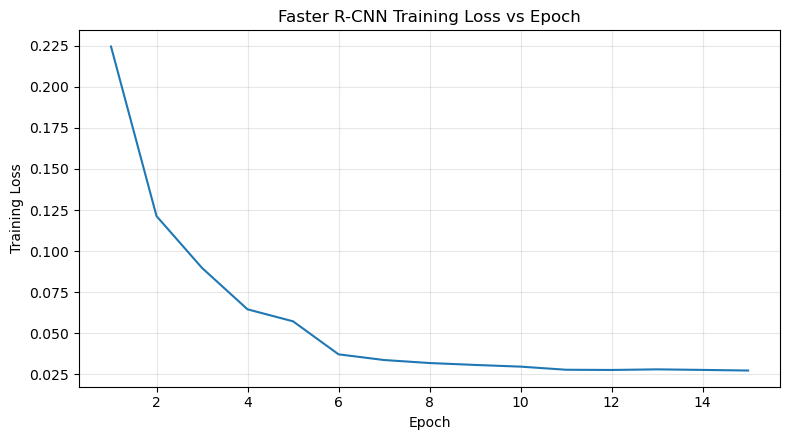

In [3]:
# USING HISTORY.JSON TO OBTAIN A PLOT FOR THE EVALUATION
import json
import matplotlib.pyplot as plt
from pathlib import Path

HISTORY_PATH = Path(r"C:\Users\nicho\OneDrive\University\Year 3\CV\Project\ARI3129 - Assignment Materials\ARI3129 - Assignment Materials\runs\ari3129\fasterrcnn_sign_type_v1\history.json")

with open(HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

# Handle both list-of-dicts and dict-of-lists formats
def as_list_of_dicts(hist):
    if isinstance(hist, list):
        return hist
    if isinstance(hist, dict):
        keys = list(hist.keys())
        n = len(hist[keys[0]])
        return [{k: hist[k][i] for k in keys} for i in range(n)]
    raise ValueError("Unsupported history.json format")

rows = as_list_of_dicts(history)

# Auto-detect training loss key
loss_key = next(
    k for k in rows[0].keys()
    if "loss" in k.lower() and "val" not in k.lower()
)

epochs = (
    [r["epoch"] for r in rows]
    if "epoch" in rows[0]
    else list(range(1, len(rows) + 1))
)

losses = [r[loss_key] for r in rows]

# Plot
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Faster R-CNN Training Loss vs Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
CSV_PATH = Path(r"C:\Users\nicho\OneDrive\University\Year 3\CV\Project\ARI3129 - Assignment Materials\ARI3129 - Assignment Materials\runs\ari3129\analytics_sign_type\sign_type_analytics.csv")

df = pd.read_csv(CSV_PATH)

# Detection count statistics
total_images = df.shape[0]
total_detections = df["total_signs_detected"].sum()
mean_detections = df["total_signs_detected"].mean()
max_detections = df["total_signs_detected"].max()

summary_table = pd.DataFrame({
    "Metric": [
        "Total test images analysed",
        "Total traffic signs detected",
        "Mean signs per image",
        "Maximum signs in a single image"
    ],
    "Value": [
        total_images,
        total_detections,
        round(mean_detections, 2),
        int(max_detections)]})

print("\nDetection Count Statistics:")
print(summary_table)

# Distribution of detected sign types
sign_type_columns = [
    col for col in df.columns
    if col not in ["image", "total_signs_detected"]]

sign_type_distribution = (df[sign_type_columns].sum().reset_index())

sign_type_distribution.columns = ["Sign Type", "Count"]

print("\nDetected Sign Type Distribution:")
print(sign_type_distribution)


Detection Count Statistics:
                            Metric   Value
0       Total test images analysed  110.00
1     Total traffic signs detected  141.00
2             Mean signs per image    1.28
3  Maximum signs in a single image    3.00

Detected Sign Type Distribution:
                    Sign Type  Count
0  Blind-Spot Mirror (Convex)     22
1          No Entry (One Way)     23
2    No Through Road (T-Sign)     28
3         Pedestrian Crossing     23
4            Roundabout Ahead     26
5                        Stop     19
